# Coursework Set Week 7

In [ ]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [17]:
import numpy as np
import sympy as sp
import scipy.integrate as spi

class Integrator:
    def __init__(self, func, a, b):
        self.a = a
        self.b = b
        self.x_sym = sp.Symbol('x')
        self.expr = sp.sympify(func)
        self.f = sp.lambdify(self.x_sym, self.expr, 'numpy')

    def trapezium(self, N=100):
        x = np.linspace(self.a, self.b, N)
        y = self.f(x)
        dx = (self.b - self.a) / (N - 1)
        integral = (dx / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
        return integral

    def simpson(self, N=101):
        x = np.linspace(self.a, self.b, N)
        y = self.f(x)
        dx = (self.b - self.a) / (N - 1)
        integral = (dx / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])
        return integral

    def monte_carlo(self, N=100000):
        x_rand = np.linspace(self.a, self.b, N)
        y_rand = self.f(x_rand)
        integral = (self.b - self.a) * np.mean(y_rand)
        return integral

    def sympy_int(self):
        exact_integral = sp.integrate(self.expr, (self.x_sym, self.a, self.b))
        return float(exact_integral.evalf())

    def scipy_int(self):
        result = spi.quad(self.f, self.a, self.b)[0]
        return result


my_calc = Integrator("1 + x + sin(2*x)", 0.5, 3.0)

print(my_calc.trapezium())
print(my_calc.simpson())
print(my_calc.monte_carlo())
print(my_calc.sympy_int())
print(my_calc.scipy_int())

6.665110635777089
6.665066002317341
6.66507513468611
6.665066009608887
6.6650660096088865


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

Text(0, 0.5, 'JY/BEAM')

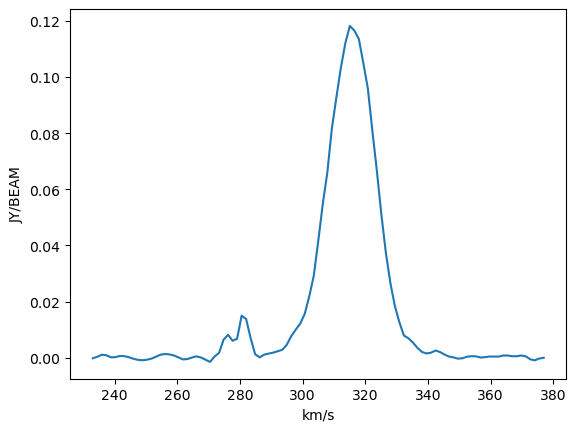

In [44]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

hdul = fits.open("ngc6946.fits")
data = hdul[0].data
header = hdul[0].header

fig, ax = plt.subplots()
ax.plot(np.linspace(233, 377, 101), data[:,55,58])
ax.set_xlabel(header["CUNIT3"])
ax.set_ylabel(header["BUNIT"])


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [58]:
import numpy as np

def f(x, amp, mu, sigma, zero):
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2) + zero

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

In [ ]:
"""
Well if you differentiate with respect to x, amp, mu or sigma the result will still contain all the other variables and not is not
constant, so its not linear
"""

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [70]:
import scipy as sp

velocities = np.linspace(233, 377, 101)
profile = data[:,55,58]
p0_amp = np.max(profile) - np.min(profile) # I take the maximum value, but take away the minimum to remove the offset we see in the top graph
p0_mu = velocities[np.argmax(profile)] # gets index of the max point for y and takes that velocity since it is in the center visually
p0_sigma = (np.max(velocities) - np.min(velocities)) / 15 # the peak looks to be about 15% of the range
p0_zero = np.min(profile) # the lowest amount of noise value is probably the best background 

popt, pcov = sp.optimize.curve_fit(f, velocities, profile, p0=[p0_amp, p0_mu, p0_sigma, p0_zero])

err = np.sqrt(np.diag(pcov))

print("Best Fit Parameters:")
print(f"Amplitude: {popt[0]} +/- {err[0]}")
print(f"Center: {popt[1]} +/- {err[1]}")
print(f"Width: {popt[2]} +/- {err[2]}")
print(f"Offset: {popt[3]} +/- {err[3]}")

Best Fit Parameters:
Amplitude: 0.11693859403224785 +/- 0.001097850996891315
Center (mu): 315.7168474497381 +/- 0.07718010727818607
Width (sigma): 7.261065888056198 +/- 0.08169689903770083
Offset (zero): 0.0013435919301106117 +/- 0.00030506232733228025


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

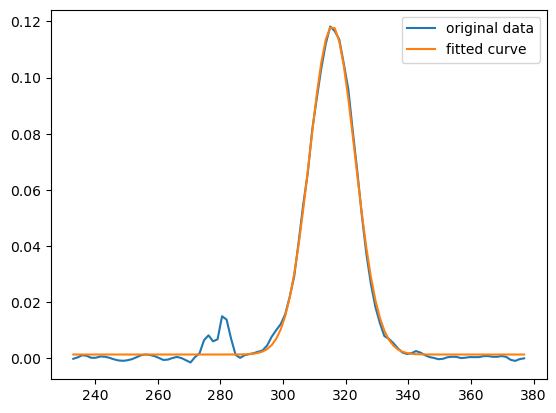

In [13]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from astropy.io import fits

hdul = fits.open("ngc6946.fits")# for some reason it stopped seeing the above variables so i had to copy and paste everythign down
data = hdul[0].data
header = hdul[0].header

def f(x, amp, mu, sigma, zero):
    return amp * np.exp(-0.5 * ((x - mu) / sigma)**2) + zero


velocities = np.linspace(233, 377, 101)
profile = data[:,55,58]
p0_amp = np.max(profile) - np.min(profile) # I take the maximum value, but take away the minimum to remove the offset we see in the top graph
p0_mu = velocities[np.argmax(profile)] # gets index of the max point for y and takes that velocity since it is in the center visually
p0_sigma = (np.max(velocities) - np.min(velocities)) / 15 # the peak looks to be about 15% of the range
p0_zero = np.min(profile) # the lowest amount of noise value is probably the best background 

popt, pcov = sp.optimize.curve_fit(f, velocities, profile, p0=[p0_amp, p0_mu, p0_sigma, p0_zero])

err = np.sqrt(np.diag(pcov))

fitted_profile = f(velocities, popt[0], popt[1], popt[2], popt[3])

fig, ax = plt.subplots() 

ax.plot(velocities, profile, label="original data")
ax.plot(velocities, fitted_profile, label="fitted curve")
ax.legend()

In [ ]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

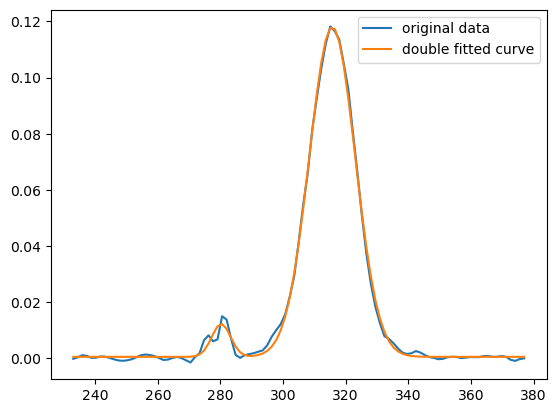

In [14]:
def double_f(x, amp1, mu1, sigma1, amp2, mu2, sigma2, zero):
    return (amp1 * np.exp(-0.5 * ((x - mu1) / sigma1)**2)) + (amp2 * np.exp(-0.5 * ((x - mu2) / sigma2)**2)) + zero

p0_amp2 = p0_amp * 0.2 
p0_mu2 = p0_mu - 25 
p0_sigma2 = p0_sigma 

popt, pcov = sp.optimize.curve_fit(double_f, velocities, profile, p0=[p0_amp, p0_mu, p0_sigma, p0_amp2, p0_mu2, p0_sigma2, p0_zero])

fitted_profile = double_f(velocities, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5], popt[6])

fig, ax = plt.subplots() 
ax.plot(velocities, profile, label="original data")
ax.plot(velocities, fitted_profile, label="double fitted curve")
ax.legend()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [19]:
err = np.sqrt(np.diag(pcov))
factor = 2 * np.sqrt(2 * np.log(2))

fwhm_main = popt[2] * factor
err_main = err[2] * factor

fwhm_sec = popt[5] * factor
err_sec = err[5] * factor

print(f"main peak FWHM: {fwhm_main} +- {err_main} km/s")
print(f"secondary peak FWHM: {fwhm_sec} +- {err_sec} km/s")

main peak FWHM: 17.271777443488652 +- 0.11045780271069053 km/s
secondary peak FWHM: 7.115625634335249 +- 0.683893457989365 km/s


In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

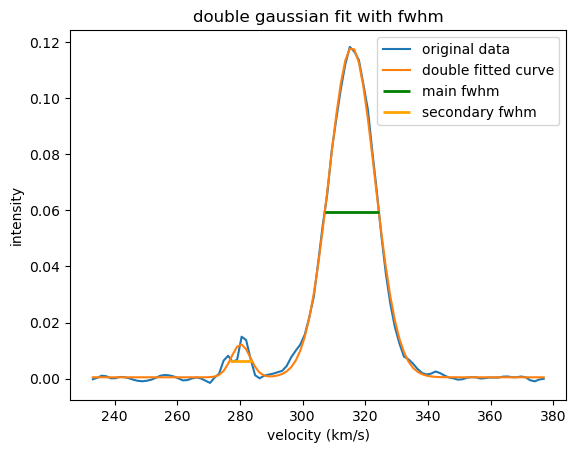

In [20]:
half_max_main = (popt[0] / 2) + popt[6]
half_max_sec = (popt[3] / 2) + popt[6]

xmin_main = popt[1] - (fwhm_main / 2)
xmax_main = popt[1] + (fwhm_main / 2)

xmin_sec = popt[4] - (fwhm_sec / 2)
xmax_sec = popt[4] + (fwhm_sec / 2)

fig, ax = plt.subplots() 

ax.plot(velocities, profile, label="original data")
ax.plot(velocities, fitted_profile, label="double fitted curve")

ax.hlines(half_max_main, xmin_main, xmax_main, color='green', linewidth=2, label="main fwhm")
ax.hlines(half_max_sec, xmin_sec, xmax_sec, color='orange', linewidth=2, label="secondary fwhm")

ax.set_xlabel("velocity (km/s)")
ax.set_ylabel("intensity")
ax.set_title("double gaussian fit with fwhm")
ax.legend()

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   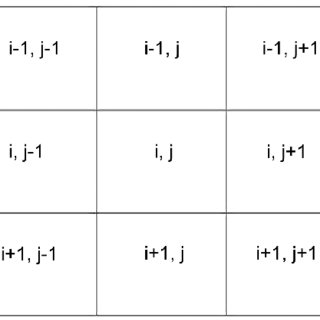    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

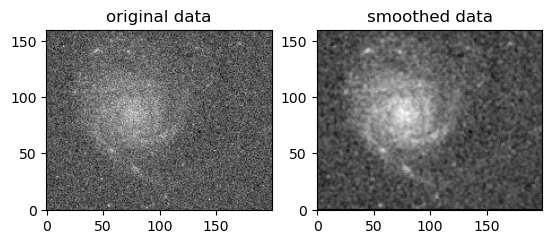

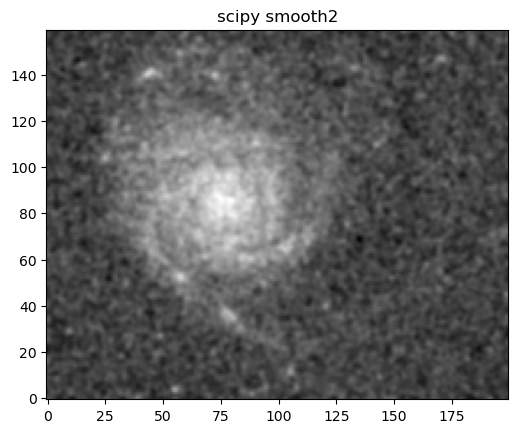

In [6]:
from astropy.io import fits
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

hdul = fits.open("faintgalaxy.fits")
m = hdul[0].data

def smooth(m):
    mc = np.zeros_like(m)
    ny, nx = m.shape
    for y in range(1, ny-1):
        for x in range(1, nx-1):
            mc[y, x] = np.mean(m[y-1:y+2, x-1:x+2])
    return mc

def smooth2(m):
    mc = sp.ndimage.gaussian_filter(m, sigma=(1,1), order=0)
    return mc

mc = smooth(m)
mc2 = smooth2(m)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(m, cmap='gray', origin='lower')
ax[0].set_title("original data")
ax[1].imshow(mc, cmap='gray', origin='lower')
ax[1].set_title("smoothed data")

fig2, ax2 = plt.subplots()
ax2.imshow(mc2, cmap='gray', origin='lower')
ax2.set_title("scipy smooth2")

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")